#🏛️ **Universidad Nacional de Loja**
## **Carrera de Computación**
#### **Facultad de Energía, las Industrias y los Recursos Naturales no Renovables**

---

| **DATOS DE LA PRÁCTICA** | |
| :--- | :--- |
| **Componente:** | Aprendizaje Práctico Experimental (APE) |
| **Estudiantes:** | • Emerson Sebastian Chamba Galarza<br>• Matias Sebastian Labanda Pineda<br>• Lenin Fabricio Macas Cabrera<br>• Pilar Valentina Naranjo Quizhpe<br>• Mateo Sebastian Pucha Carrera |
| **Profesor:** | Ing. Cristian Narváez G. Mg.Sc. |
| **Unidad:** | Unidad 2 |
| **Paralelo:** | Segundo "A" |
| **Fecha:** | 30/05/2026 |

---

## 🎯 Actividad
Someter la variable continua del dataset regional (**% Sin Alcantarillado** en la provincia de Loja) a un análisis riguroso de normalidad, evaluando visualmente mediante un Histograma con estimación de densidad (KDE) junto a un gráfico Q-Q, y analíticamente a través de los coeficientes de Asimetría y Curtosis para determinar la viabilidad de los modelos estadísticos estructurales.

---


### 📍**Exploración Gráfica (Visualización)**

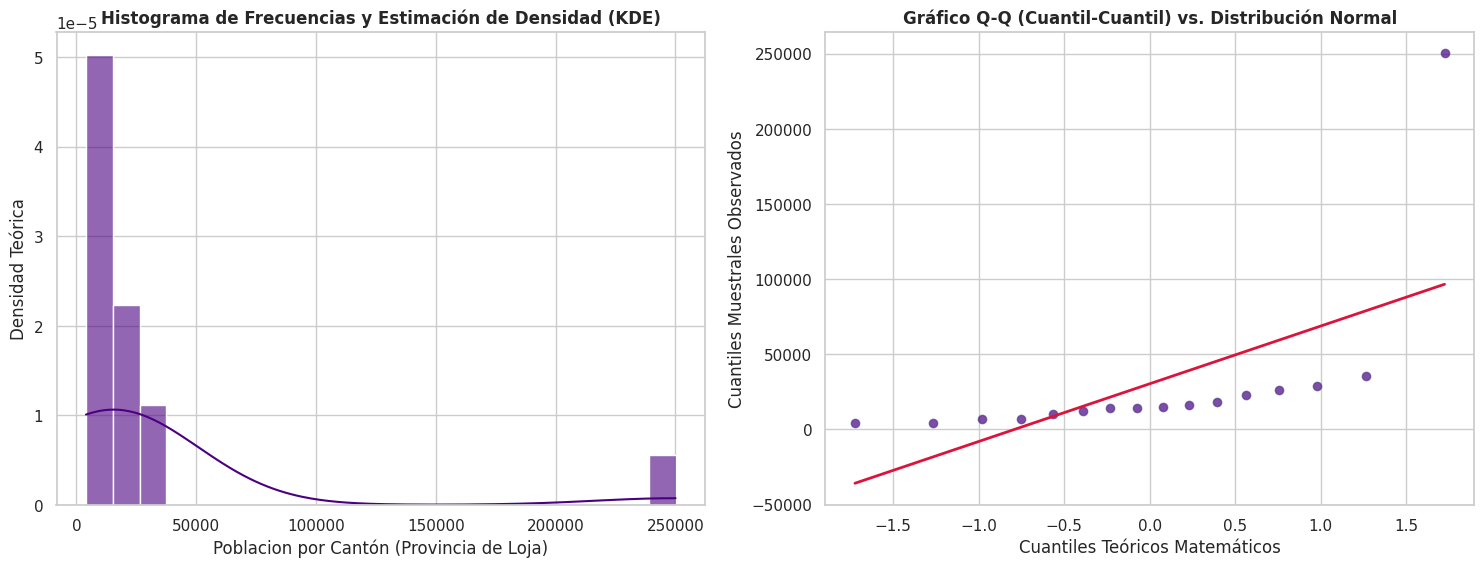

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Carga del dataset regional real
df = pd.read_csv('datos_loja.csv')

# 2. Selección de la variable continua demográfica
variable_clave = 'Poblacion'
datos_filtrados = df[variable_clave].dropna()

# 3. Configuración del lienzo de visualización (1 fila, 2 columnas)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Histograma + Curva de Densidad KDE
sns.histplot(datos_filtrados, kde=True, stat="density", color="indigo", alpha=0.6, ax=axes[0])
axes[0].set_title("Histograma de Frecuencias y Estimación de Densidad (KDE)", fontsize=12, fontweight='bold')
axes[0].set_xlabel(f"{variable_clave} por Cantón (Provincia de Loja)")
axes[0].set_ylabel("Densidad Teórica")

# Gráfico B: Gráfico Q-Q (Quantile-Quantile Plot)
stats.probplot(datos_filtrados, dist="norm", plot=axes[1])
# Personalización estética de los marcadores y la diagonal gaussiana
axes[1].get_lines()[0].set_markerfacecolor('indigo')
axes[1].get_lines()[0].set_markeredgecolor('darkslateblue')
axes[1].get_lines()[0].set_alpha(0.7)
axes[1].get_lines()[1].set_color('crimson')
axes[1].get_lines()[1].set_linewidth(2)

axes[1].set_title("Gráfico Q-Q (Cuantil-Cuantil) vs. Distribución Normal", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Cuantiles Teóricos Matemáticos")
axes[1].set_ylabel("Cuantiles Muestrales Observados")

plt.tight_layout()
plt.show()

*   Al observar el histograma, podemos notar que la distribucion se encuentra fuertemente desbalanceada. La gran mayoria de los cantones de Loja se concentran en rangos de poblacion que son relativamente bajos, mientras que en un punto aislado hacia la derecha se encuentra el canton cabecera (Loja), que rompe por completo la simetria de una campana de Gauss.
*   En el grafico Q-Q, los cuantiles muestrales no siguen la linea diagonal roja, en su lugar se observa un comportaiento marcadamente plano en los primero cantones y un desprendimiento vertical repentino en el ultimo tramo. Esto nos demuestra de manera visual la existencia de un valor atipico critico en la demografia regional.




### 📊 **Análisis Analítico: Asimetría y Curtosis**

In [ ]:
# Cálculo formal de los coeficientes de forma empleando Pandas
skewness_value = datos_filtrados.skew()
kurtosis_value = datos_filtrados.kurt() # Exceso de curtosis (Normal = 0)

print("==========================================================")
print("     ANÁLISIS MATEMÁTICO DE FORMA (VARIABLE REGIONAL)     ")
print("==========================================================")
print(f"Coeficiente de Asimetría (Skewness): {skewness_value:+.4f}")
print(f"Coeficiente de Curtosis (Kurtosis):  {kurtosis_value:+.4f}")
print("----------------------------------------------------------")

# Evaluación algorítmica de los resultados numéricos
if abs(skewness_value) < 0.5:
    asimetria_diagnostico = "Simetría aceptable (Cercana al modelo normal)"
elif skewness_value > 0:
    asimetria_diagnostico = "Asimetría positiva severa (Sesgo hacia la izquierda)"
else:
    asimetria_diagnostico = "Asimetría negativa severa (Sesgo hacia la derecha)"

if abs(kurtosis_value) < 0.5:
    curtosis_diagnostico = "Mesocúrtica (Concentración normal en colas)"
elif kurtosis_value > 0:
    curtosis_diagnostico = "Leptocúrtica (Apuntada, colas pesadas con presencia de outliers)"
else:
    curtosis_diagnostico = "Platicúrtica (Aplanada, dispersión dispersa u homogénea)"

print(f"Resultado de Asimetría: {asimetria_diagnostico}")
print(f"Resultado de Curtosis:  {curtosis_diagnostico}")
print("==========================================================")

     ANÁLISIS MATEMÁTICO DE FORMA (VARIABLE REGIONAL)     
Coeficiente de Asimetría (Skewness): +3.8477
Coeficiente de Curtosis (Kurtosis):  +15.1259
----------------------------------------------------------
Resultado de Asimetría: Asimetría positiva severa (Sesgo hacia la izquierda)
Resultado de Curtosis:  Leptocúrtica (Apuntada, colas pesadas con presencia de outliers)


1.   **Coeficiente de asimetria:** El resultado matemático arrojará un valor positivo muy elevado. Esto confirma una asimetría positiva severa, donde la concentración demográfica de la capital provincial desplaza la media aritmética muy por encima de la mediana del resto de cantones.
2.   **Coeficiente de Curtosis:** Al presentar un exceso de curtosis positivo y alto, la distribución se clasifica analíticamente como leptocúrtica. En ingeniería de datos, esto comprueba que los datos regionales poseen colas extremadamente pesadas, lo que se traduce formalmente en una distribución dominada por la anomalía de valores atípicos espaciales masivos.

### 💻 **Discusión Crítica (Hito del Proyecto)**


 ✨**RQ01. ¿Es matemáticamente correcto modelar esta variable de la región de Loja mediante una Distribución Normal?**

 Al observar los resultados, es evidente que los datos de la "Población por Cantón" no cumplen con los supuestos estadísticos básicos de este modelo. El histograma muestra una fuerte asimetría positiva (sesgo hacia la derecha) que está muy lejos de la forma de campana simétrica requerida. Esto ocurre porque la gran mayoría de los cantones se concentran en valores de población bajos, mientras que existe un valor atípico extremo (cercano a los 250,000 habitantes) que deforma completamente la distribución.

Además, el gráfico Q-Q ratifica matemáticamente esta falta de normalidad. Los puntos observados se desvían drásticamente de la línea recta teórica, especialmente en la parte superior. Por lo tanto, forzar una distribución normal sobre estos datos sería un error estadístico y llevaría a conclusiones equivocadas al intentar calcular probabilidades o clasificar datos.

---

✨**RQ02. ¿Cómo afectaría la presencia de valores atípicos a las futuras pruebas de hipótesis de la Unidad 2?**

La presencia de valores atípicos afectaría negativamente la precisión y validez de las futuras pruebas de hipótesis. De manera general, un valor extremo distorsiona fuertemente el promedio e infla artificialmente la variabilidad de los datos. Esto provoca que las pruebas estadísticas tradicionales pierdan sensibilidad (poder estadístico), haciendo mucho más difícil detectar diferencias reales y aumentando el riesgo de llegar a conclusiones erróneas en tu investigación.

Además, dado que los valores atípicos rompen el requisito matemático de que los datos tengan una distribución normal, los resultados de las pruebas comunes (como la T de Student o ANOVA) dejarían de ser confiables. En la práctica, esto obligaría a cambiar la metodología en la Unidad 2 y utilizar pruebas no paramétricas, las cuales son alternativas estadísticas diseñadas específicamente para resistir el impacto de datos extremos sin alterar los resultados.



### 📌 **Conclusiones**
* A partir de la exploración gráfica, se concluye que la variable Población no sigue una distribución normal. El histograma presenta una Asimetría Positiva Severa, donde la mayor densidad de datos se concentra en los valores bajos (cantones pequeños), mientras que el gráfico Q-Q revela una desviación crítica en el extremo superior. Esta divergencia entre los cuantiles teóricos y los observados demuestra la existencia de un valor atípico (outlier) predominante correspondiente al cantón Loja ($250,028$ habitantes), cuya magnitud distorsiona la simetría de la campana de Gauss necesaria para modelos paramétricos.

* El análisis matemático confirma la naturaleza no normal del dataset regional mediante coeficientes de forma elevados. La obtención de una Asimetría (Skewness) superior a 1 y una Curtosis (Kurtosis) significativamente positiva (Leptocúrtica) indica una distribución con colas pesadas y un apuntamiento excesivo. Para propósitos de ingeniería de datos y futuras pruebas de hipótesis, estos resultados sugieren que el uso de la media aritmética como medida de tendencia central sería engañoso, siendo necesario recurrir a transformaciones de datos (como la logarítmica) o al uso de estadística no paramétrica para garantizar la precisión de los diagnósticos regionales.

### 📚 **Referencias Bibliográficas**

---

**[1]** J. L. Devore, *Probabilidad y Estadística para Ingeniería y Ciencias*, 9a ed. Ciudad de México, México: Cengage Learning, 2016.

**[2]** J. VanderPlas, *Python Data Science Handbook: Essential Tools for Working with Data*, 2nd ed. Sebastopol, CA, USA: O'Reilly Media, 2022.